In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import json
from fiftyone import ViewField as F
import matplotlib.pyplot as plt
import numpy as np


## renders plotly properly in a html instance. 
import plotly.io as pio
pio.renderers.default = "notebook"

# init

In [3]:
# load dataset
dataset = fo.load_dataset("dugong")


In [4]:
## load views
nc_view = dataset.load_saved_view('nc')
wp_view = dataset.load_saved_view('wp')

## load saved test view
test_view_seed0 = dataset.load_saved_view('wp_test_s0')
test_view_seed63 = dataset.load_saved_view('wp_test_s63')
test_view_seed72 = dataset.load_saved_view('wp_test_s72')

# List Evauations


In [73]:
## load the views
#nc_view = dataset.load_saved_view("nc")
#wp_view = dataset.load_saved_view("wp")
## launch session
session = fo.launch_app(dataset,
                        port=5151,
                        auto=False)


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


In [5]:
eval_of_seed0 = ['ACLR_p10_SEED0_nms',
 'ACLR_p10_SEED0_raw',
 'ACLR_p25_SEED0_nms',
 'ACLR_p25_SEED0_raw',
 'ACLR_p50_SEED0_nms',
 'ACLR_p50_SEED0_raw',
 'ACLR_p5_SEED0_nms',
 'ACLR_p5_SEED0_raw',
 'ACLR_p75_SEED0_nms',
 'ACLR_p75_SEED0_raw',
 'baseline_SEED0_nms',
 'baseline_SEED0_raw',
 'p100_SEED0_nms',
 'p100_SEED0_raw',
 'p10_SEED0_nms',
 'p10_SEED0_raw',
 'p25_SEED0_nms',
 'p25_SEED0_raw',
 'p50_SEED0_nms',
 'p50_SEED0_raw',
 'p5_SEED0_nms',
 'p5_SEED0_raw',
 'p75_SEED0_nms',
 'p75_SEED0_raw']

In [6]:
not_seed0_eval = [eval for eval in dataset.list_evaluations() if eval not in eval_of_seed0]
not_seed0_eval

['ACLR_p10_SEED63_nms',
 'ACLR_p25_SEED63_nms',
 'ACLR_p50_SEED63_nms',
 'ACLR_p5_SEED63_nms',
 'ACLR_p75_SEED63_nms',
 'baseline_SEED63_nms',
 'baseline_SEED63_raw',
 'p10_SEED63_nms',
 'p25_SEED63_nms',
 'p50_SEED63_nms',
 'p5_SEED63_nms']

In [7]:
for eval in not_seed0_eval:
    print(f"deleting:{eval}")
    dataset.delete_evaluation(eval)

deleting:ACLR_p10_SEED63_nms


deleting:ACLR_p25_SEED63_nms
deleting:ACLR_p50_SEED63_nms
deleting:ACLR_p5_SEED63_nms
deleting:ACLR_p75_SEED63_nms
deleting:baseline_SEED63_nms
deleting:baseline_SEED63_raw
deleting:p10_SEED63_nms
deleting:p25_SEED63_nms
deleting:p50_SEED63_nms
deleting:p5_SEED63_nms


In [16]:
sample = test_view_seed0.first()
det = sample.ground_truth.detections[0]
print(det)  # look for the eval_baseline_SEED0_raw attribute

<Detection: {
    'id': '69add896cfd942e1c6b5c58e',
    'attributes': {},
    'tags': [],
    'label': 'Dugong',
    'bounding_box': [
        0.5018274853801169,
        0.05317982456140351,
        0.01699561403508772,
        0.04276315789473684,
    ],
    'mask': None,
    'mask_path': None,
    'confidence': None,
    'index': None,
    'patch_embeddings': array([-0.5978058 , -0.2737485 , -0.10805661, ...,  0.3813876 ,
           -0.8690382 ,  0.094939  ], shape=(1024,), dtype=float32),
    'dinov3_patch_umap': [67.82942199707031, -16.23343849182129],
    'region': 'WP',
    'subregion': 'MANTASANDY',
    'patch_emb_dinov3_tsne': [67.82942199707031, -16.23343849182129],
    'patch_10expansion_embeddings': array([-0.45114323, -0.08667576,  0.02824171, ...,  0.368037  ,
           -0.8975529 ,  0.04690378], shape=(1024,), dtype=float32),
    'patch_25expansion_embeddings': array([-0.49457765, -0.10710227, -0.00820985, ...,  0.4157841 ,
           -0.8661041 ,  0.05185848], shape=(1

In [15]:
# Samples where at least one GT detection was missed by the baseline
fn_view = test_view_seed0.match(
    F("ground_truth.detections").filter(
        F("baseline_SEED0_raw") == "fn"
    ).length() > 0
)

fn_view

Dataset:     dugong
Media type:  image
Num samples: 20
Sample fields:
    id:                                             fiftyone.core.fields.ObjectIdField
    filepath:                                       fiftyone.core.fields.StringField
    tags:                                           fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                                       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                                     fiftyone.core.fields.DateTimeField
    last_modified_at:                               fiftyone.core.fields.DateTimeField
    region:                                         fiftyone.core.fields.StringField
    subregion:                                      fiftyone.core.fields.StringField
    mission_name:                                   fiftyone.core.fields.StringField
    sea_state:                                      fiftyone.core.fields.IntFie

In [17]:
session.view = fn_view

In [8]:
def create_eval_key_name(ds_field_name):
    splits = ds_field_name.split('_')

    if 'ACLR' in splits:
        part = splits[3]
        seed = splits[4]
        raw = splits[-1]
        return f"ACLR_p{part}_{seed}_{raw}"
    else:
        part = splits[2]
        seed = splits[3]
        raw = splits[-1]
        return f"p{part}_{seed}_{raw}"


def filter_ops(all_op, 
               nms_or_raw=None, 
               seed_term=None):
    def match(op):
        tokens = op.split('_')

        if nms_or_raw and nms_or_raw not in tokens:
            return False

        if seed_term and seed_term not in tokens:
            return False

        return True

    return [op for op in all_op if match(op)]


def select_evaluation_list(
    all_op,
    nms_or_raw='raw',
    baseline_field='baseline',
    seed_term=None,  
):
    nms_or_raw = nms_or_raw.strip().lower()

    evaluation_list = filter_ops(
        all_op,
        nms_or_raw=nms_or_raw,
        seed_term=seed_term
    )

    models_ft = [
        {
            "pred_field": r,
            "eval_key": create_eval_key_name(r),
        }
        for r in evaluation_list
    ]

    if nms_or_raw not in {"raw", "nms"}:
        raise ValueError(f"Invalid nms_or_raw value: {nms_or_raw}")

    models_ft.append({
        "pred_field": baseline_field,
        "eval_key": f"baseline_{seed_term}_{nms_or_raw}",
    })


    return models_ft

In [11]:
all_op = [
 'NWW_ACLR_partition_10_SEED0_augm_0429_1026_raw',
 'NWW_ACLR_partition_10_SEED0_augm_0429_1026_nms',
 'NWW_ACLR_partition_25_SEED0_augm_0430_0302_raw',
 'NWW_ACLR_partition_25_SEED0_augm_0430_0302_nms',
 'NWW_ACLR_partition_50_SEED0_augm_0430_0357_raw',
 'NWW_ACLR_partition_50_SEED0_augm_0430_0357_nms',
 'NWW_ACLR_partition_5_SEED0_augm_0429_0948_raw',
 'NWW_ACLR_partition_5_SEED0_augm_0429_0948_nms',
 'NWW_ACLR_partition_75_SEED0_augm_0430_0525_raw',
 'NWW_ACLR_partition_75_SEED0_augm_0430_0525_nms',
 'NWW_partition_100_SEED0_augm_0429_0941_raw',
 'NWW_partition_100_SEED0_augm_0429_0941_nms',
 'NWW_partition_10_SEED0_augm_0429_0445_raw',
 'NWW_partition_10_SEED0_augm_0429_0445_nms',
 'NWW_partition_25_SEED0_augm_0429_0531_raw',
 'NWW_partition_25_SEED0_augm_0429_0531_nms',
 'NWW_partition_50_SEED0_augm_0429_0704_raw',
 'NWW_partition_50_SEED0_augm_0429_0704_nms',
 'NWW_partition_5_SEED0_augm_0429_0140_raw',
 'NWW_partition_5_SEED0_augm_0429_0140_nms',
 'NWW_partition_75_SEED0_augm_0429_0941_raw',
 'NWW_partition_75_SEED0_augm_0429_0941_nms',
]


In [9]:
sss_seed0 = select_evaluation_list(
    all_op= all_op,
    nms_or_raw='nms',
     seed_term='SEED0',
    baseline_field='NNN_NC_SEED0_augm_0422_2254conf_50_nms'
)
sss_seed0

[{'pred_field': 'NWW_ACLR_partition_10_SEED0_augm_0429_1026_nms',
  'eval_key': 'ACLR_p10_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_25_SEED0_augm_0430_0302_nms',
  'eval_key': 'ACLR_p25_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_50_SEED0_augm_0430_0357_nms',
  'eval_key': 'ACLR_p50_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_5_SEED0_augm_0429_0948_nms',
  'eval_key': 'ACLR_p5_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_75_SEED0_augm_0430_0525_nms',
  'eval_key': 'ACLR_p75_SEED0_nms'},
 {'pred_field': 'NWW_partition_100_SEED0_augm_0429_0941_nms',
  'eval_key': 'p100_SEED0_nms'},
 {'pred_field': 'NWW_partition_10_SEED0_augm_0429_0445_nms',
  'eval_key': 'p10_SEED0_nms'},
 {'pred_field': 'NWW_partition_25_SEED0_augm_0429_0531_nms',
  'eval_key': 'p25_SEED0_nms'},
 {'pred_field': 'NWW_partition_50_SEED0_augm_0429_0704_nms',
  'eval_key': 'p50_SEED0_nms'},
 {'pred_field': 'NWW_partition_5_SEED0_augm_0429_0140_nms',
  'eval_key': 'p5_SEED0_nms'},
 {'pred_field': 'NWW_p

In [29]:
# check for duplicates
from collections import Counter
pred_fields = [d['pred_field'] for d in sss_seed0]
dups = [k for k, v in Counter(pred_fields).items() if v > 1]

print(dups)

[]


In [ ]:
# DROP DUPLICATE AND LEAVE BASELINE
seen = {}

for item in sss_seed0:
    key = item['pred_field']
    
    if key not in seen:
        seen[key] = item
    else:
        # if duplicate exists, prefer baseline
        if "baseline" in item['eval_key']:
            seen[key] = item
        elif "baseline" not in seen[key]['eval_key']:
            # neither is baseline → keep first (do nothing)
            pass
        # else: existing is baseline → ignore current duplicate

sss_seed0 = list(seen.values())
sss_seed0

In [10]:
# Reload evaluation
results_seed0 = {}
for model in sss_seed0:
    results_seed0[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])
results_seed0

{'ACLR_p10_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef8017f8e90>,
 'ACLR_p25_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80168a550>,
 'ACLR_p50_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801f41590>,
 'ACLR_p5_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170c7d0>,
 'ACLR_p75_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801cb82d0>,
 'p100_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170d810>,
 'p10_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef8016f2350>,
 'p25_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801724550>,
 'p50_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170e190>,
 'p5_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801726050>,
 'p75_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170f9d0>,
 'baseline_SEED0_nms': <fiftyone.utils.ev

# Evaluate what metric to use

if Equal Error Rate of F1 Optimal Threshold

── F1-Optimal ──────────────────────────────────
  Threshold : 0.517
  F1        : 0.796
  Precision : 0.816
  Recall    : 0.777
  TP/FP/FN  : 80 / 18 / 23

── Equal Error Rate ────────────────────────────
  Threshold : 0.010
  FN rate   : 0.223
  FP rate   : 0.192
  Precision : 0.808
  Recall    : 0.777
  TP/FP/FN  : 80 / 19 / 23


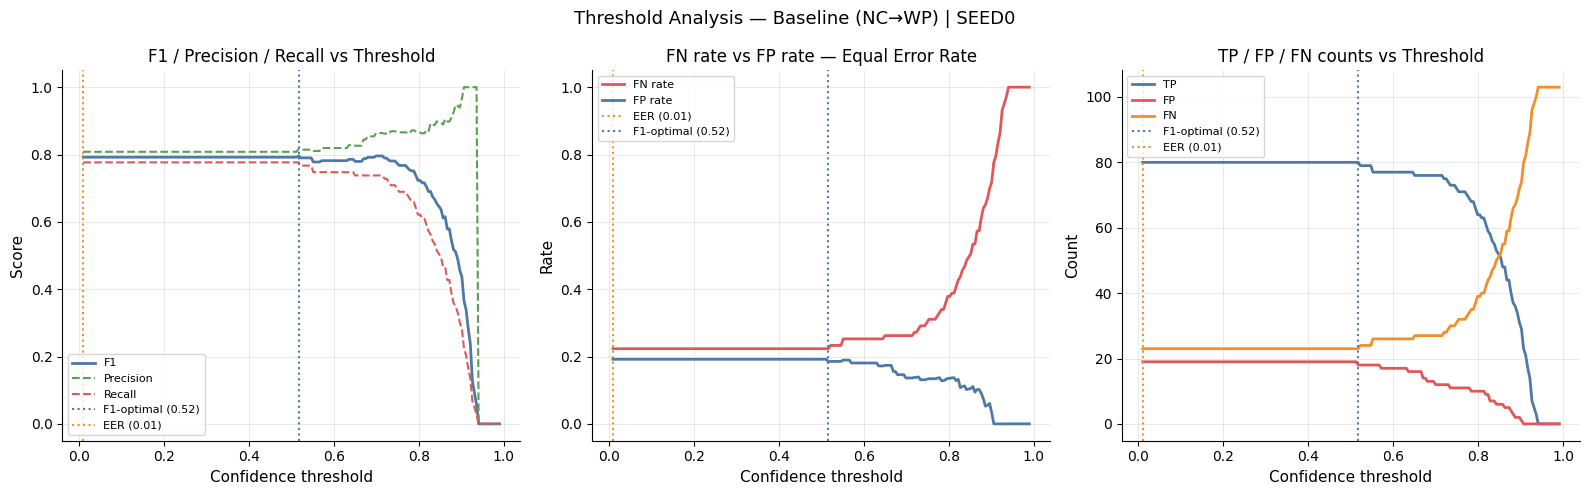

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed0["baseline_SEED0_nms"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r0.9074["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Baseline (NC→WP) | SEED0", fontsize=13)
plt.tight_layout()
plt.savefig("threshold_analysis_baseline_seed0.png", dpi=300, bbox_inches="tight")
plt.show()

── F1-Optimal ──────────────────────────────────
  Threshold : 0.862
  F1        : 0.932
  Precision : 0.932
  Recall    : 0.932
  TP/FP/FN  : 96 / 7 / 7

── Equal Error Rate ────────────────────────────
  Threshold : 0.862
  FN rate   : 0.068
  FP rate   : 0.068
  Precision : 0.932
  Recall    : 0.932
  TP/FP/FN  : 96 / 7 / 7


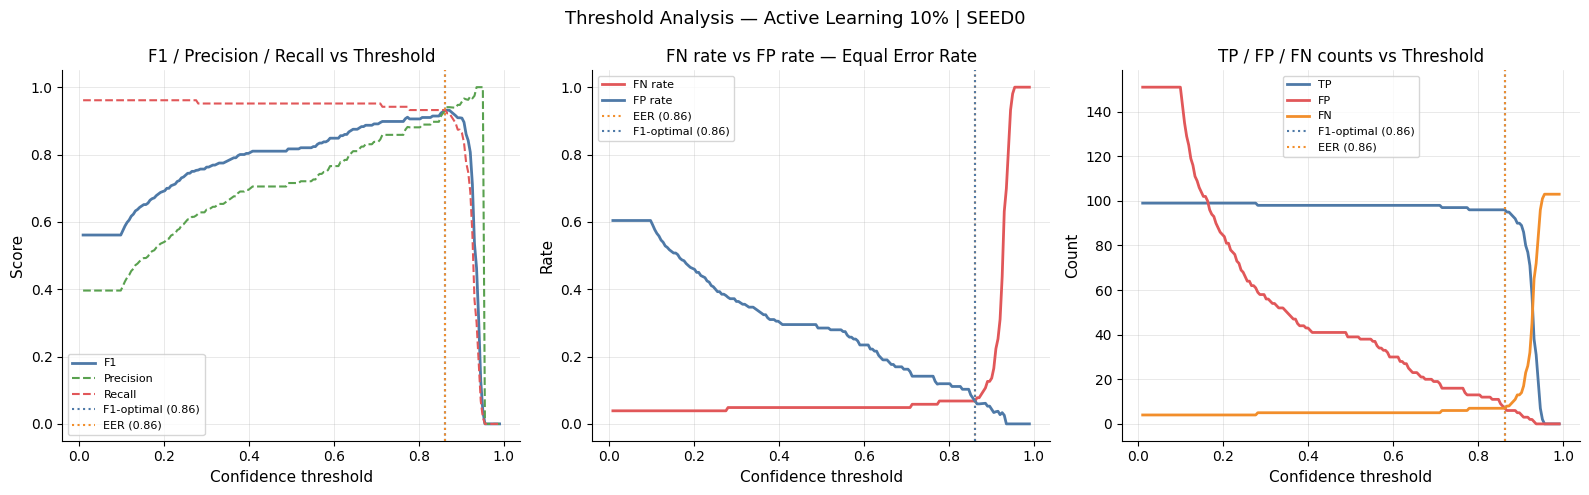

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed0["ACLR_p25_SEED0_nms"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Active Learning 10% | SEED0", fontsize=13)
plt.tight_layout()
#plt.savefig("threshold_analysis_baseline_seed0.png", dpi=300, bbox_inches="tight")
plt.show()

# Compute Evaluation

In [38]:
from src.evaluation_metric import extract_all_metrics, select_evaluation_list

In [14]:
## results seed is loaded from evaluation_results ! 

df_metrics = extract_all_metrics(
    results_seed0,
    seed=0
)
df_metrics

Seed 0 done — 12 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,0,ACLR_p10_SEED0_nms,0.735509,0.810680,0.842261,0.925234,0.891892,0.961165,99,12,4,103
1,0,ACLR_p25_SEED0_nms,0.735868,0.802913,0.861960,0.932039,0.932039,0.932039,96,7,7,103
2,0,ACLR_p50_SEED0_nms,0.760379,0.819417,0.857035,0.947368,0.933962,0.961165,99,7,4,103
3,0,ACLR_p5_SEED0_nms,0.703725,0.783495,0.857035,0.907407,0.867257,0.951456,98,15,5,103
4,0,ACLR_p75_SEED0_nms,0.763416,0.831068,0.886583,0.960784,0.970297,0.951456,98,3,5,103
5,0,p100_SEED0_nms,0.759095,0.832039,0.891508,0.942857,0.925234,0.961165,99,8,4,103
6,0,p10_SEED0_nms,0.692694,0.775728,0.916131,0.866310,0.964286,0.786408,81,3,22,103
7,0,p25_SEED0_nms,0.728966,0.795146,0.842261,0.919431,0.898148,0.941748,97,11,6,103
8,0,p50_SEED0_nms,0.757307,0.816505,0.891508,0.927536,0.923077,0.932039,96,8,7,103
9,0,p5_SEED0_nms,0.645778,0.733010,0.778241,0.862385,0.817391,0.912621,94,21,9,103


In [15]:
folder = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/evaluation'
filename = 'evaluation_all_runs_seed0.csv'
df_metrics.to_csv(os.path.join(folder,filename))

In [22]:
## raw
# sss_seed0_raw = select_evaluation_list(
#     all_op= all_op,
#     nms_or_raw='raw',
#      seed_term='SEED0',
#     baseline_field='NNN_NC_SEED0_augm_0422_2254conf_50_raw'
# )
# sss_seed0_raw
## results seed is loaded from evaluation_results ! 
## collect results 
#Reload evaluation
results_seed0 = {}
for model in sss_seed0:
    results_seed0[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])

df_metrics = extract_all_metrics(
    results_seed0,
    seed=0
)
df_metrics

Seed 0 done — 12 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,0,ACLR_p10_SEED0_raw,0.685724,0.828155,0.906281,0.843602,0.824074,0.864078,89,19,14,103
1,0,ACLR_p25_SEED0_raw,0.705845,0.828155,0.901357,0.853081,0.833333,0.873786,90,18,13,103
2,0,ACLR_p50_SEED0_raw,0.727862,0.839806,0.896432,0.846847,0.789916,0.912621,94,25,9,103
3,0,ACLR_p5_SEED0_raw,0.672854,0.817476,0.901357,0.820276,0.780702,0.864078,89,25,14,103
4,0,ACLR_p75_SEED0_raw,0.722053,0.844660,0.901357,0.850467,0.819820,0.883495,91,20,12,103
5,0,p100_SEED0_raw,0.685135,0.848544,0.906281,0.812227,0.738095,0.902913,93,33,10,103
6,0,p10_SEED0_raw,0.670436,0.819417,0.916131,0.801980,0.818182,0.786408,81,18,22,103
7,0,p25_SEED0_raw,0.701188,0.827184,0.901357,0.829493,0.789474,0.873786,90,24,13,103
8,0,p50_SEED0_raw,0.712989,0.832039,0.901357,0.855856,0.798319,0.922330,95,24,8,103
9,0,p5_SEED0_raw,0.651479,0.801942,0.891508,0.807175,0.750000,0.873786,90,30,13,103


In [21]:

# Run evaluation --- SEED0 RAW
results = {}
for m in sss_seed0_raw:
    results[m["eval_key"]] = test_view_seed0.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,  
        compute_mAP=True,
    )

Evaluating detections...
 100% |█████████████████| 103/103 [650.9ms elapsed, 0s remaining, 158.2 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 103/103 [594.3ms elapsed, 0s remaining, 173.3 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [612.5ms elapsed, 0s remaining, 168.2 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 103/103 [607.5ms elapsed, 0s remaining, 169.5 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [1.2s elapsed, 0s remaining, 83.4 samples/s]          
Performing IoU sweep...
 100% |█████████████████| 103/103 [974.6ms elapsed, 0s remaining, 107.2 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [641.4ms elapsed, 0s remaining, 160.6 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 103/103 [634.8ms elapsed, 0s remaining, 162.2 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [601.5ms elapsed, 0s remaining, 1

In [ ]:
import pandas as pd
from pathlib import Path

def extract_metrics(results_dict: dict, seed: int) -> pd.DataFrame:
    """
    Extract scalar metrics from a dict of COCODetectionResults.
    results_dict: {eval_key: COCODetectionResults}
    """
    rows = []
    for eval_key, res in results_dict.items():
        # Parse eval_key to extract metadata
        # e.g. "eval_NWW_ACLR_p10_S0" → schema=NWW, method=ACLR, partition=10, seed=0
        sweep, best_f1, best_eer = find_optimal_threshold(res)

        rows.append({
            "eval_key":        eval_key,
            "seed":            seed,
            "mAP":             res.mAP(),
            "mAR":             res.mAR(),
            "f1_thresh":       best_f1["threshold"],
            "f1_optimal":      best_f1["f1"],
            "f1_precision":    best_f1["precision"],
            "f1_recall":       best_f1["recall"],
            "f1_tp":           best_f1["tp"],
            "f1_fp":           best_f1["fp"],
            "f1_fn":           best_f1["fn"],
            "eer_thresh":      best_eer["threshold"],
            "eer_fn_rate":     best_eer["fn_rate"],
            "eer_fp_rate":     best_eer["fp_rate"],
        })

    return pd.DataFrame(rows)


# Run for each seed and accumulate
all_metrics = []
for seed, results_dict in [
    (0,  results_seed0),
    (10, results_seed10),
    (63, results_seed63),
]:
    df_seed = extract_metrics(results_dict, seed=seed)
    all_metrics.append(df_seed)

df_all = pd.concat(all_metrics, ignore_index=True)
df_all.to_parquet("evaluation_results_all_seeds.parquet")
print(df_all.head())

# Seed63

In [9]:
check = os.listdir('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1')

In [10]:
check

['NNN_NC_SEED63_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED63_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10',
 'NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10',
 'NNN_NC_SEED63_baseline72_augm_0511_2138_conf_10']

In [11]:
## find the name of the folders 
import os 
listed_dir = sorted(check)
listed_dir

['NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10',
 'NNN_NC_SEED63_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED63_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED63_baseline72_augm_0511_2138_conf_10',
 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10']

In [11]:
## get by seed
sied = 'SEED63'
out_list = []
for line in listed_dir:
    for word in line.split('_'):
        if sied == word:
            out_list.append(line)
        else:
            pass

out_list

['NNN_NC_SEED63_augm_0510_1843',
 'NNN_NC_SEED63_augm_0510_1843_conf_10',
 'NWW_ACLR_partition_10_SEED63_augm_0510_2124',
 'NWW_ACLR_partition_25_SEED63_augm_0510_2333',
 'NWW_ACLR_partition_50_SEED63_augm_0510_2333',
 'NWW_ACLR_partition_5_SEED63_augm_0510_2121',
 'NWW_ACLR_partition_75_SEED63_augm_0510_2337',
 'NWW_partition_10_SEED63_augm_0510_2120',
 'NWW_partition_25_SEED63_augm_0510_2337',
 'NWW_partition_50_SEED63_augm_0511_0035',
 'NWW_partition_5_SEED63_augm_0510_2120']

In [12]:
final_out_list = ['NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10',
 'NNN_NC_SEED63_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED63_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED63_baseline72_augm_0511_2138_conf_10',
 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10',
 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10',
 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10']

In [13]:
## reconstruct into fiftyone
root_folder_ = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1'

list_folders_jj = [os.path.join(root_folder_,l) for l in final_out_list]
list_folders_jj

['/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED63_baseline10_augm_0422_2254_conf_10',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED63_baseline63_augm_0510_1843_conf_10',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED63_baseline72_augm_0511_2138_conf_10',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inf

In [14]:
## import function 
from reconstruct import reconstruct_predictions, reconstruct_and_nms

In [15]:
def extract_stem(path):
    return Path(path).stem

# import func and reconstruct 

for prediction in list_folders_jj:
    name_field = extract_stem(prediction)
    ## apply non-maximumm supression
    reconstruct_and_nms(
        dataset=dataset,
        predictions_dir=prediction,
        field_name=name_field,
        tile_size=640
    )

2026-05-12 17:46:47.984 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10'
2026-05-12 17:46:48.014 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 369 JSONs → 99 unique sample stems
2026-05-12 17:46:48.016 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 99 / 2755 samples to JSONs
2026-05-12 17:46:54.567 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10_raw' 
2026-05-12 17:46:54.570 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10_nms'


 100% |███████████████████| 99/99 [6.2s elapsed, 0s remaining, 19.1 samples/s]      


2026-05-12 17:47:00.840 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10_nms' saved | detections before NMS: 245 | after NMS: 178 | suppressed: 67 (27.3%)
2026-05-12 17:47:00.841 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10'
2026-05-12 17:47:00.866 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 384 JSONs → 103 unique sample stems
2026-05-12 17:47:00.870 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 103 / 2755 samples to JSONs
2026-05-12 17:47:07.617 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10_raw' 
2026-05-12 17:47:07.620 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35)

 100% |█████████████████| 103/103 [7.1s elapsed, 0s remaining, 17.2 samples/s]      


2026-05-12 17:47:14.733 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10_nms' saved | detections before NMS: 183 | after NMS: 141 | suppressed: 42 (23.0%)
2026-05-12 17:47:14.734 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10'
2026-05-12 17:47:14.760 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 710 JSONs → 200 unique sample stems
2026-05-12 17:47:14.765 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 200 / 2755 samples to JSONs
2026-05-12 17:47:24.792 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10_raw' 
2026-05-12 17:47:24.795 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35)

...

2026-05-12 17:48:18.695 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10_nms' saved | detections before NMS: 213 | after NMS: 168 | suppressed: 45 (21.1%)
2026-05-12 17:48:18.696 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10'
2026-05-12 17:48:18.839 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 662 JSONs → 201 unique sample stems
2026-05-12 17:48:18.844 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 201 / 2755 samples to JSONs
2026-05-12 17:48:29.099 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_raw' 
2026-05-12 17:48:29.103 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.

 100% |█████████████████| 201/201 [9.0s elapsed, 0s remaining, 19.5 samples/s]      


2026-05-12 17:48:38.168 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_nms' saved | detections before NMS: 274 | after NMS: 218 | suppressed: 56 (20.4%)
2026-05-12 17:48:38.170 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/experiment1/NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10'
2026-05-12 17:48:38.194 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 333 JSONs → 100 unique sample stems
2026-05-12 17:48:38.200 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 100 / 2755 samples to JSONs
2026-05-12 17:48:42.145 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_raw' 
2026-05-12 17:48:42.154 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.

 100% |█████████████████| 100/100 [3.5s elapsed, 0s remaining, 37.8 samples/s]      


2026-05-12 17:48:45.686 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_nms' saved | detections before NMS: 110 | after NMS: 91 | suppressed: 19 (17.3%)


In [19]:
which_seed = "_baseline"
all_fields = dataset.get_field_schema().keys()
baseline_fields = [f for f in all_fields if which_seed in f]

baseline_fields_raw = [f for f in baseline_fields if "raw" in f]
baseline_fields_nms = [f for f in baseline_fields if "nms" in f]
baseline_fields_excluding_evaluation = [
    f for f in baseline_fields if not any(x in f for x in ['tp', 'tn', 'fp','fn'])
]
baseline_fields_excluding_evaluation

['NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10_raw',
 'NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10_nms',
 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10_raw',
 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10_nms',
 'NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10_raw',
 'NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10_nms',
 'NNN_NC_SEED63_baseline10_augm_0422_2254_conf_10_raw',
 'NNN_NC_SEED63_baseline10_augm_0422_2254_conf_10_nms',
 'NNN_NC_SEED63_baseline63_augm_0510_1843_conf_10_raw',
 'NNN_NC_SEED63_baseline63_augm_0510_1843_conf_10_nms',
 'NNN_NC_SEED63_baseline72_augm_0511_2138_conf_10_raw',
 'NNN_NC_SEED63_baseline72_augm_0511_2138_conf_10_nms',
 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10_raw',
 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10_nms',
 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_raw',
 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_nms',
 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_raw',
 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_nms'

In [33]:
evals = [
    'TEST_SEED0_baseline10',
    'TEST_SEED0_baseline63',
    'TEST_SEED0_baseline72',
    'TEST_SEED63_baseline10',
    'TEST_SEED63_baseline63',
    'TEST_SEED63_baseline72',
    'TEST_SEED72_baseline10',
    'TEST_SEED72_baseline63',
    'TEST_SEED72_baseline72',
    ]

models = []
for i in zip(baseline_fields_nms,evals):
    models_dict = {}
    models_dict['eval_key'] = i[1]
    models_dict['pred_field'] = i[0]
    models.append(models_dict)
models

[{'eval_key': 'TEST_SEED0_baseline10',
  'pred_field': 'NNN_NC_SEED0_baseline10_augm_0422_2254_conf_10_nms'},
 {'eval_key': 'TEST_SEED0_baseline63',
  'pred_field': 'NNN_NC_SEED0_baseline63_augm_0510_1843_conf_10_nms'},
 {'eval_key': 'TEST_SEED0_baseline72',
  'pred_field': 'NNN_NC_SEED0_baseline72_augm_0511_2138_conf_10_nms'},
 {'eval_key': 'TEST_SEED63_baseline10',
  'pred_field': 'NNN_NC_SEED63_baseline10_augm_0422_2254_conf_10_nms'},
 {'eval_key': 'TEST_SEED63_baseline63',
  'pred_field': 'NNN_NC_SEED63_baseline63_augm_0510_1843_conf_10_nms'},
 {'eval_key': 'TEST_SEED63_baseline72',
  'pred_field': 'NNN_NC_SEED63_baseline72_augm_0511_2138_conf_10_nms'},
 {'eval_key': 'TEST_SEED72_baseline10',
  'pred_field': 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10_nms'},
 {'eval_key': 'TEST_SEED72_baseline63',
  'pred_field': 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_nms'},
 {'eval_key': 'TEST_SEED72_baseline72',
  'pred_field': 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_nms'}

In [34]:
seed0_dicts = [
    d for d in models
    if 'SEED0' in d['pred_field']
]
seed63_dicts = [
    d for d in models
    if 'SEED63' in d['pred_field']
]
seed72_dicts = [
    d for d in models
    if 'SEED72' in d['pred_field']
]

In [31]:
test_view_seed0 = dataset.match_tags('test_0').match(F("region")=='WP')
# test_view_seed63 = dataset.load_saved_view('wp_test_s63')
# test_view_seed72 = dataset.load_saved_view('wp_test_s72')

In [35]:
# compute evaluations for each test view 
# --- Run evaluations ---
results0 = {}
for m in seed0_dicts:
    results0[m["eval_key"]] = test_view_seed0.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,        # single class (dugong), no need to enforce classwise
        compute_mAP=True,
    )

results63 = {}
for m in seed63_dicts:
    results63[m["eval_key"]] = test_view_seed63.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,        # single class (dugong), no need to enforce classwise
        compute_mAP=True,
    )

results72 = {}
for m in seed72_dicts:
    results72[m["eval_key"]] = test_view_seed72.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,        # single class (dugong), no need to enforce classwise
        compute_mAP=True,
    )

Evaluating detections...
 100% |█████████████████| 103/103 [1.0s elapsed, 0s remaining, 99.5 samples/s]          
Performing IoU sweep...
 100% |█████████████████| 103/103 [1.1s elapsed, 0s remaining, 99.1 samples/s]         
Evaluating detections...
 100% |█████████████████| 103/103 [1.0s elapsed, 0s remaining, 101.1 samples/s]        
Performing IoU sweep...
 100% |█████████████████| 103/103 [1.0s elapsed, 0s remaining, 103.2 samples/s]         
Evaluating detections...
 100% |█████████████████| 103/103 [1.6s elapsed, 0s remaining, 97.5 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 103/103 [1.1s elapsed, 0s remaining, 95.8 samples/s]         
Evaluating detections...
 100% |█████████████████| 104/104 [1.0s elapsed, 0s remaining, 99.2 samples/s]          
Performing IoU sweep...
 100% |█████████████████| 104/104 [843.6ms elapsed, 0s remaining, 123.3 samples/s]      
Evaluating detections...
 100% |█████████████████| 104/104 [936.9ms elapsed, 0s remaining, 111.0 sa

In [36]:
results0

{'TEST_SEED0_baseline10': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ff022f6e690>,
 'TEST_SEED0_baseline63': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ff022fa29d0>,
 'TEST_SEED0_baseline72': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7feeea7fd4d0>}

In [ ]:

## reload evaluations 
# # Reload evaluation
# results_seed63 = {}
# for model in sss_seed63:
#     results_seed63[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])
# results_seed63

── F1-Optimal ──────────────────────────────────
  Threshold : 0.104
  F1        : 0.423
  Precision : 0.436
  Recall    : 0.411
  TP/FP/FN  : 65 / 84 / 93

── Equal Error Rate ────────────────────────────
  Threshold : 0.010
  FN rate   : 0.589
  FP rate   : 0.570
  Precision : 0.430
  Recall    : 0.411
  TP/FP/FN  : 65 / 86 / 93


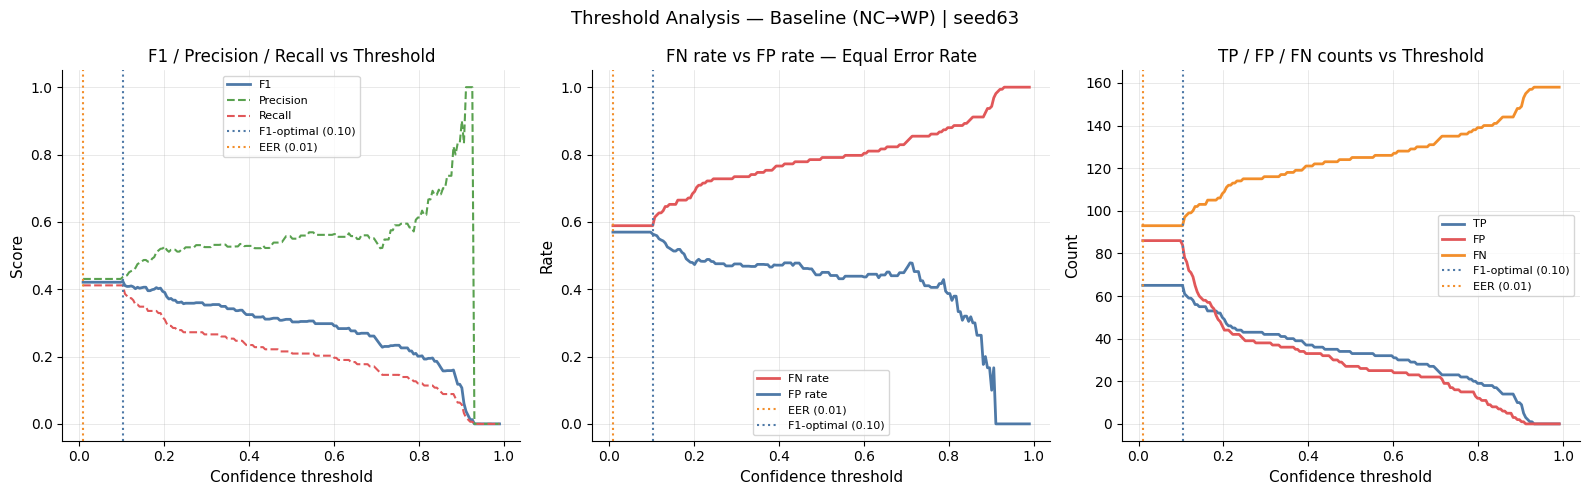

In [34]:
## check the optimal threshold
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed63["baseline_SEED63_raw"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Baseline (NC→WP) | seed63", fontsize=13)
plt.tight_layout()
#plt.savefig("threshold_analysis_baseline_seed63.png", dpi=300, bbox_inches="tight")
plt.show()

## compute evaluation

In [37]:
## results seed is loaded from evaluation_results ! 

df_metrics = extract_all_metrics(
    results0,
    seed=0
)
df_metrics

NameError: name 'extract_all_metrics' is not defined

── F1-Optimal ──────────────────────────────────
  Threshold : 0.168
  F1        : 0.564
  Precision : 0.600
  Recall    : 0.532
  TP/FP/FN  : 84 / 56 / 74

── Equal Error Rate ────────────────────────────
  Threshold : 0.133
  FN rate   : 0.449
  FP rate   : 0.460
  Precision : 0.540
  Recall    : 0.551
  TP/FP/FN  : 87 / 74 / 71


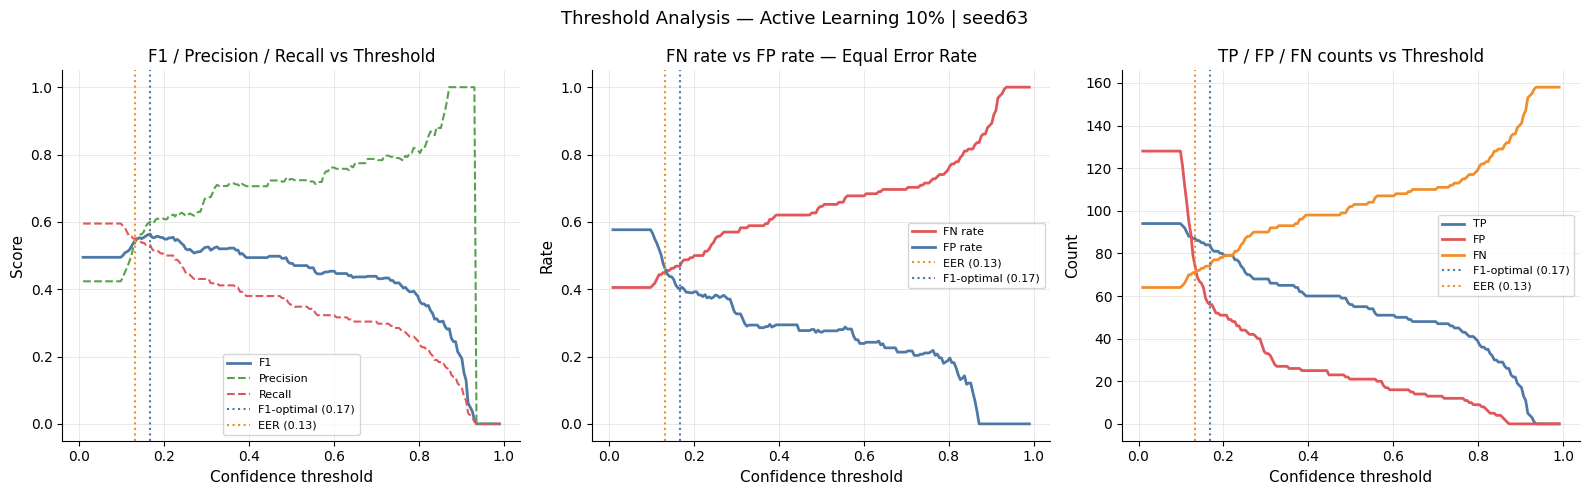

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed63["ACLR_p25_SEED63_nms"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Active Learning 10% | seed63", fontsize=13)
plt.tight_layout()
#plt.savefig("threshold_analysis_baseline_seed63.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
## results seed is loaded from evaluation_results ! 

df_metrics_0 = extract_all_metrics(
    results0,
    seed=0
)
df_metrics_0

Seed 0 done — 3 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,0,TEST_SEED0_baseline10,0.569886,0.678641,0.374422,0.788177,0.800000,0.776699,80,20,23,103
1,0,TEST_SEED0_baseline63,0.583578,0.700971,0.271005,0.823529,0.831683,0.815534,84,17,19,103
2,0,TEST_SEED0_baseline72,0.641037,0.733010,0.241457,0.867925,0.844037,0.893204,92,17,11,103


In [42]:
df_metrics_63 = extract_all_metrics(
    results63,
    seed=63
)
df_metrics_63

Seed 63 done — 3 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,63,TEST_SEED63_baseline10,0.184442,0.277215,0.202060,0.450909,0.529915,0.392405,62,55,96,158
1,63,TEST_SEED63_baseline63,0.160036,0.233544,0.103568,0.446886,0.530435,0.386076,61,54,97,158
2,63,TEST_SEED63_baseline72,0.146728,0.205063,0.133116,0.396761,0.550562,0.310127,49,40,109,158


In [43]:
df_metrics_72 = extract_all_metrics(
    results72,
    seed=72
)
df_metrics_72

Seed 72 done — 3 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,72,TEST_SEED72_baseline10,0.251798,0.319277,0.167588,0.487805,0.578512,0.421687,70,51,96,166
1,72,TEST_SEED72_baseline63,0.258901,0.298795,0.010000,0.501845,0.647619,0.409639,68,37,98,166
2,72,TEST_SEED72_baseline72,0.247829,0.279518,0.010000,0.482490,0.681319,0.373494,62,29,104,166


In [44]:
df_metrics_72.columns

Index(['seed', 'eval_key', 'mAP', 'mAR', 'threshold', 'f1', 'precision',
       'recall', 'tp', 'fp', 'fn', 'n_gt'],
      dtype='str')

In [55]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
 
def plot_crossbaseline(df_metrics_0: pd.DataFrame,
                       df_metrics_63: pd.DataFrame,
                       df_metrics_72: pd.DataFrame,
                       output_dir: str = "."):
    """
    Parameters
    ----------
    df_metrics_0, df_metrics_63, df_metrics_72 : DataFrames
        Each has columns: seed, eval_key, mAP, mAR, threshold, f1,
        precision, recall, tp, fp, fn, n_gt.
        Rows correspond to the three NC baselines evaluated on that
        test seed's WP test set.
    output_dir : str
        Directory where PNG and PDF are saved.
    """
 
    # ── Build a unified long-form structure ──────────────────────────────
    # test_seed_label → df
    dfs = {
        "WP Test\nSEED: 0":  df_metrics_0,
        "WP Test\nSEED: 63": df_metrics_63,
        "WP Test\nSEED: 72": df_metrics_72,
    }
    test_seeds = list(dfs.keys())
 
    # Extract baseline labels from eval_key (e.g. "TEST_SEED0_baseline10" → "baseline10")
    def _bl_label(eval_key: str) -> str:
        return eval_key.split("_")[-1]   # "baseline10" / "baseline63" / "baseline72"
 
    PRETTY = {"baseline10": "Baseline 0",
               "baseline63": "Baseline 63",
               "baseline72": "Baseline 72"}
 
    # Collect all baseline keys present (union across dfs)
    all_baselines = []
    for df in dfs.values():
        for ek in df["eval_key"]:
            bl = _bl_label(ek)
            if bl not in all_baselines:
                all_baselines.append(bl)
 
    # ── Nested data dict: test_seed → baseline → (mAP, mAR, f1) ─────────
    data = {}
    for ts_label, df in dfs.items():
        data[ts_label] = {}
        for _, row in df.iterrows():
            bl = _bl_label(row["eval_key"])
            data[ts_label][bl] = (row["mAP"], row["mAR"], row["f1"])
 
    metrics         = ["mAP", "mAR", "F1"]
    metric_keys     = ["mAP", "mAR", "f1"]
    baselines       = all_baselines
    baseline_labels = [PRETTY.get(b, b) for b in baselines]
 
    # ── Colours ───────────────────────────────────────────────────────────
    PALETTE = {
        "baseline10": "#4C72B0",
        "baseline63": "#DD8452",
        "baseline72": "#55A868",
    }
    ALPHA_BAR = 0.82
 
    # ── Layout: 1 row × 3 cols, one panel per metric ──────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
    fig.suptitle(
        "Cross-Baseline Zero-Shot Performance on WP Test Sets\n",
        fontsize=10, fontweight="bold", y=1.02,
    )
 
    x       = np.arange(len(test_seeds))
    n_bl    = len(baselines)
    width   = 0.22
    offsets = np.linspace(-(n_bl - 1) / 2 * width, (n_bl - 1) / 2 * width, n_bl)
 
    for ax, (m_name, m_key) in zip(axes, zip(metrics, metric_keys)):
 
        # ── per-test-seed: mean & std across baselines ────────────────────
        means_per_seed = {
            ts: np.mean([data[ts][bl][metric_keys.index(m_key)]
                         for bl in baselines if bl in data[ts]])
            for ts in test_seeds
        }
        stds_per_seed = {
            ts: np.std([data[ts][bl][metric_keys.index(m_key)]
                        for bl in baselines if bl in data[ts]], ddof=0)
            for ts in test_seeds
        }
 
        # ── individual baseline bars ───────────────────────────────────────
        for bl, off, bl_label in zip(baselines, offsets, baseline_labels):
            vals = [data[ts].get(bl, (np.nan, np.nan, np.nan))[metric_keys.index(m_key)]
                    for ts in test_seeds]
            ax.bar(
                x + off, vals, width,
                color=PALETTE.get(bl, "#999999"), alpha=ALPHA_BAR,
                label=bl_label, zorder=3,
            )
 
        # ── mean ± std error bars ─────────────────────────────────────────
        means = [means_per_seed[ts] for ts in test_seeds]
        stds  = [stds_per_seed[ts]  for ts in test_seeds]
 
        ax.errorbar(
            x, means, yerr=stds,
            fmt="D", color="black", markersize=4,
            capsize=2, capthick=1.5, linewidth=1.5,
            zorder=5, label="",
        )
 
        # ── mean annotation above error bar ───────────────────────────────
        for xi, (m, s) in enumerate(zip(means, stds)):
            ax.text(
                xi, m + s + 0.018, f"{m:.3f}",
                ha="center", va="bottom", fontsize=8.5,
                fontweight="bold", color="black",
            )
 
        # ── formatting ────────────────────────────────────────────────────
        ax.set_title(m_name, fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(test_seeds, fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(m_name, fontsize=10)
        ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
 
        if m_name == "mAP":
            ax.legend(fontsize=8, loc="upper right", framealpha=0.85)
 
    # ── shared caption ────────────────────────────────────────────────────
    # fig.text(
    #     0.5, -0.04,
    #     "Black diamonds show mean across the 3 NC baselines; error bars show ±1 SD.\n"
    #     "Near-zero SD within each test seed confirms WP split composition — not NC model quality — drives zero-shot performance.",
    #     ha="center", fontsize=9, style="italic", color="#444444",
    # )
 
    #plt.tight_layout()
    #import os
    #os.makedirs(output_dir, exist_ok=True)
    #plt.savefig(f"{output_dir}/crossbaseline_results.pdf", bbox_inches="tight", dpi=200)
    #plt.savefig(f"{output_dir}/crossbaseline_results.png", bbox_inches="tight", dpi=200)
    #print(f"Saved → {output_dir}/crossbaseline_results.pdf / .png")
    return fig

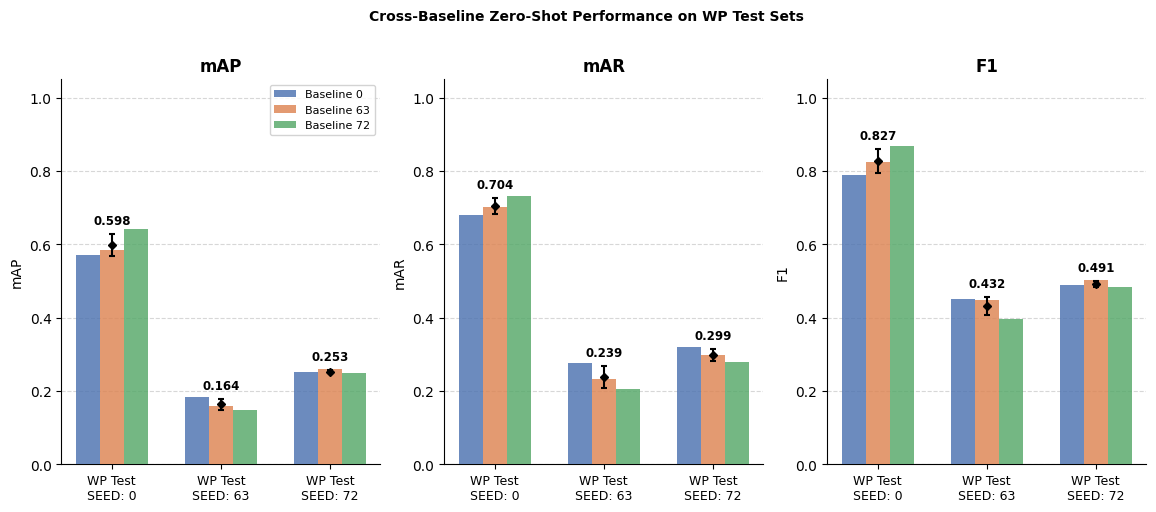

In [56]:
fig = plot_crossbaseline(
    df_metrics_0,
    df_metrics_63,
    df_metrics_72
)
fig.show()

In [58]:
# save all df
df_final = pd.concat([df_metrics_0, df_metrics_63, df_metrics_72])
df_final.to_csv('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/baseline_compare_testseeds.csv')